In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_diabetes

In [4]:
data=load_diabetes()

In [5]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [6]:
x=data.data
y=data.target

In [11]:
from sklearn.model_selection import train_test_split
x_test,x_train,y_test,y_train = train_test_split(x,y,test_size=0.2, random_state=45)

In [12]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [13]:
lr.fit(x_train,y_train)

LinearRegression()

In [16]:
y_pred = lr.predict(x_test)


In [17]:
from sklearn.metrics import r2_score, mean_squared_error

In [19]:
print("R2_score", r2_score(y_test,y_pred))
print("RMSE", np.sqrt(mean_squared_error(y_test,y_pred)))

R2_score 0.4834746845671225
RMSE 56.500941424705736


In [22]:
from sklearn.linear_model import Ridge
r= Ridge(alpha=0.0001)
# alpha = lambda

In [23]:
r.fit(x_train,y_train)

Ridge(alpha=0.0001)

In [24]:
y_pred1 = r.predict(x_test)

In [25]:
print("R2_score", r2_score(y_test, y_pred1))
print("RMSE", np.sqrt(mean_squared_error(y_test, y_pred1)))

R2_score 0.4835069166061524
RMSE 56.499178520830306


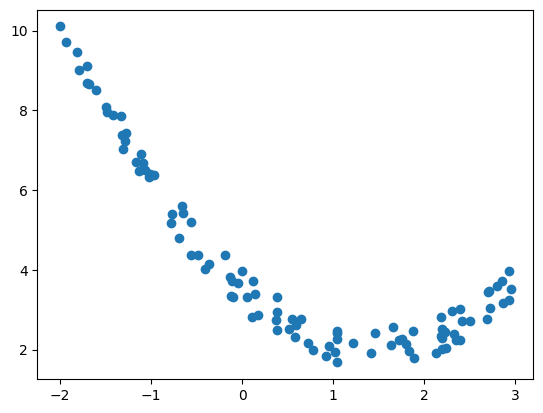

In [26]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 **2 - 2 * x1 + 3 + np.random.rand(m, 1)

plt.scatter(x1, x2)
plt.show()

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

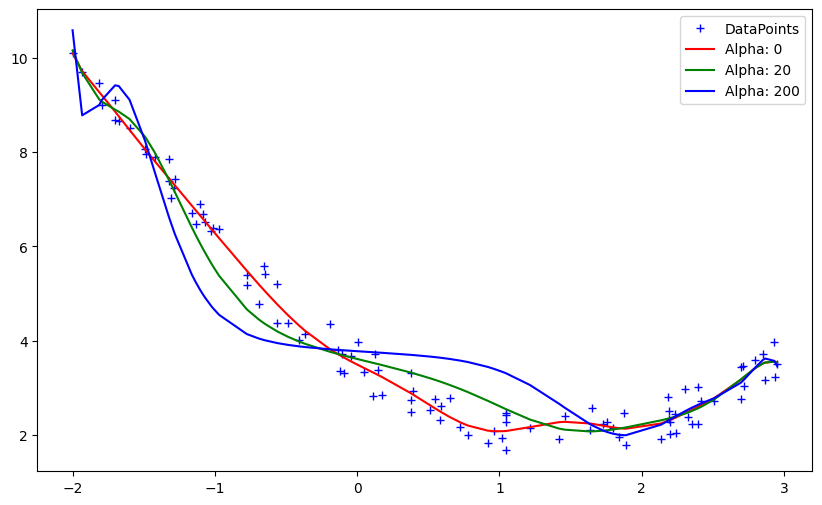

In [30]:
def get_pred_ridge(x1, x2, alpha):
    model  = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0,20,200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10,6))
plt.plot(x1,x2, 'b+', label='DataPoints')

for alpha, c in zip(alphas, cs):
    preds = get_pred_ridge(x1,x2, alpha)

    plt.plot(sorted(x1[:,0]), preds[np.argsort(x1[:,0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()